In [5]:
# !pip install gradio

In [7]:
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')

ModuleNotFoundError: No module named 'gradio'

In [3]:
SIZE = 10_000

### Playing around and plotting the different types of distribution

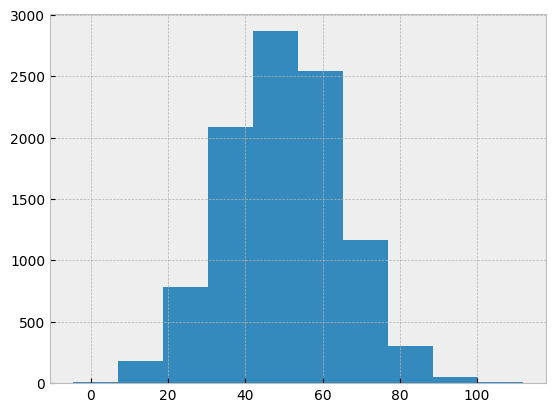

In [3]:
# normal distribution
normal_dist = np.random.normal(loc=50, scale=15, size=SIZE)
plt.hist(normal_dist)
plt.show()

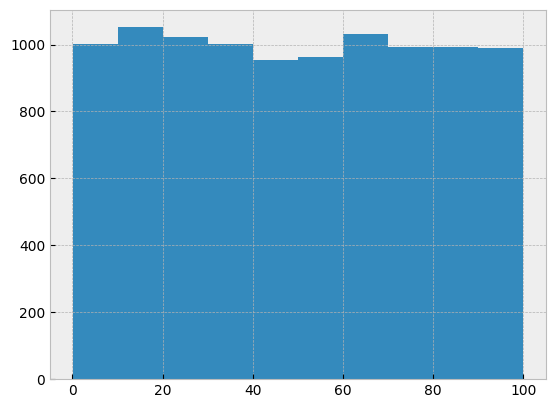

In [4]:
# uniform distribution
uniform_dist = np.random.uniform(low=0, high=100, size=SIZE)
plt.hist(uniform_dist)
plt.show()

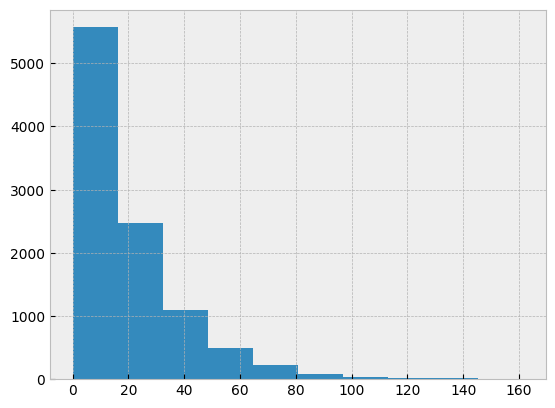

In [5]:
# exponential distribution
exponential_dist = np.random.exponential(scale=20, size=SIZE)
plt.hist(exponential_dist)
plt.show()

### Plan to add more distributions

## Simulate

Assuming user wants to simulate normal distribution

In [6]:
NUM_SIMS = 10_000

In [7]:
population_data = np.random.normal(loc=50, scale=15, size=SIZE)

In [8]:
population_median: np.float64 = np.median(population_data)

In [9]:
# generate 5 sample vectors
sample_data = np.random.choice(population_data, size=(NUM_SIMS, 5))
sample_data

array([[49.01117507, 64.49195046, 66.00992129, 65.33971355, 43.48481567],
       [40.21374074, 52.26063411, 45.43514013, 41.97679749, 34.23477982],
       [49.69366091, 55.4193422 , 65.33394567, 56.62585419, 22.17671715],
       ...,
       [54.09096914, 65.33203257, 76.94019333, 32.23550898, 21.71114091],
       [46.79191612, 41.36361195, 33.07288534, 36.09508442, 83.00112591],
       [52.41497991, 45.21199487, 33.60088885, 19.96066284, 31.06646669]],
      shape=(10000, 5))

In [10]:
sample_min = np.min(sample_data, axis=1)
sample_min

array([43.48481567, 34.23477982, 22.17671715, ..., 21.71114091,
       33.07288534, 19.96066284], shape=(10000,))

In [11]:
sample_max = np.max(sample_data, axis=1)
type(sample_max)

numpy.ndarray

In [12]:
(sample_min <= population_median) & (sample_max >= population_median)

array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,))

In [13]:
is_median_within_range_arr = np.logical_and(sample_min <= population_median, sample_max >= population_median)

In [14]:
type(np.sum(is_median_within_range_arr))

numpy.int64

In [15]:
success_count = np.sum(is_median_within_range_arr)
success_count

np.int64(9362)

In [16]:
accuracy_pct = (success_count / NUM_SIMS)*100
accuracy_pct

np.float64(93.62)

### Visualise

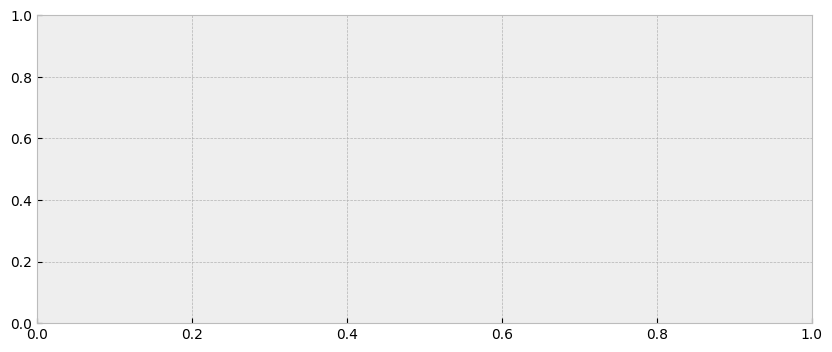

In [17]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

In [18]:
ax.hist(population_data, bins=50, color='teal', alpha=0.2, density=True, label='Population')
ax.axvline(population_median, color='crimson', linestyle='--', label='True Median')

viz_count = min(NUM_SIMS, 10)
y_pos = np.linspace(0.1, 0.9, viz_count) * ax.get_ylim()[1]
    
for i in range(viz_count):
    is_success = is_median_within_range_arr[i]
    clr = 'green' if is_success else 'red'
    
    ax.plot([sample_min, sample_max], [y_pos[i], y_pos[i]], 
            color=clr, marker='o', markersize=4, alpha=0.8)
    
    # For the very first sample, or if only 1 simulation was run, show individual dots
    if NUM_SIMS == 1 or i == 0:
        ax.scatter(sample_data[i], [y_pos[i]]*5, color=clr, s=20, edgecolors='white', zorder=5)

    ax.set_title(f"Simulation: {NUM_SIMS} Trials", loc='left', fontsize=12)
    ax.get_yaxis().set_visible(False)
    ax.legend(loc='upper right', fontsize='small')
    plt.tight_layout()

<Figure size 640x480 with 0 Axes>

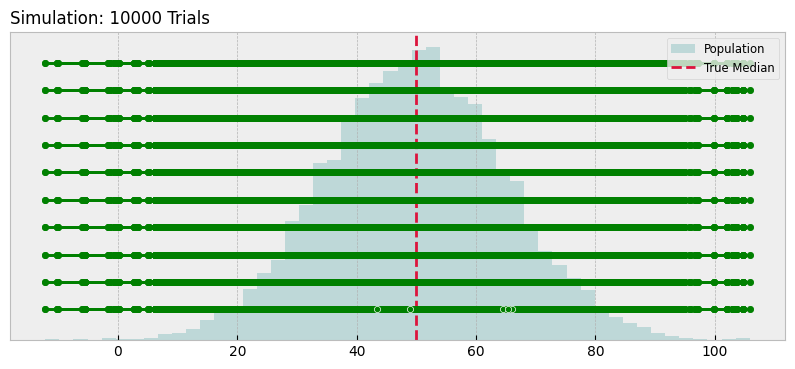

In [19]:
fig

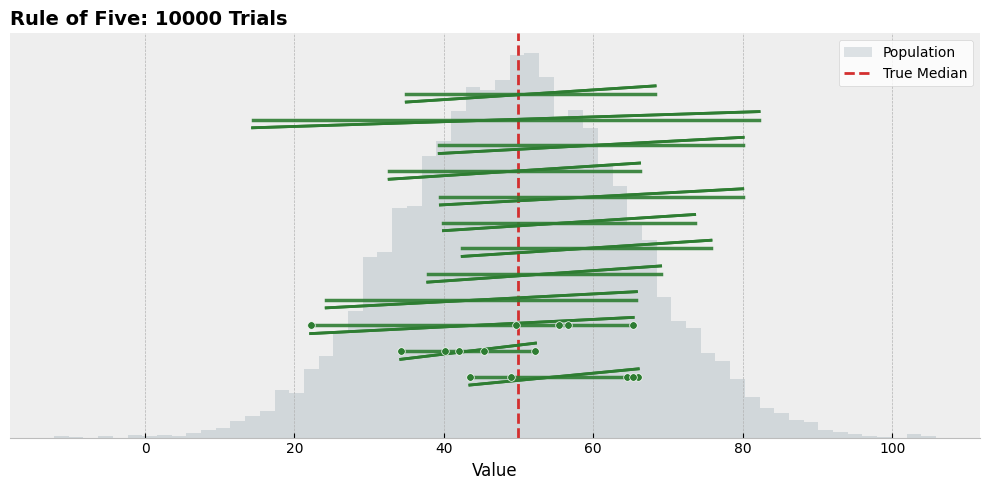

In [20]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    
# Plot population density as the 'ground truth' context
ax.hist(population_data, bins=60, color='#607d8b', alpha=0.2, density=True, label='Population')
ax.axvline(population_median, color='#d32f2f', linestyle='--', linewidth=2, label='True Median')

# Visualize the horizontal ranges for the first few samples.
# We limit this to 10-15 to maintain a clean visual look.
viz_count = min(NUM_SIMS, 12)

# Calculate vertical spacing for the ranges
y_max = ax.get_ylim()[1]
y_positions = np.linspace(y_max * 0.15, y_max * 0.85, viz_count)

for i in range(viz_count):
    is_success = is_median_within_range_arr[i]
    clr = '#2e7d32' if is_success else '#c62828' # Dark Green / Dark Red
    y = y_positions[i]
    
    # Draw the line representing the range [min, max]
    ax.plot([sample_min[i], sample_max[i]], [y, y], 
            color=clr, linewidth=2.5, alpha=0.9, zorder=3)
    
    # Add 'caps' to the range line
    ax.plot([sample_min[i], sample_max[i]], [y - y_max*0.02, y + y_max*0.02], color=clr, linewidth=2)
    ax.plot([sample_min[i], sample_max[i]], [y - y_max*0.02, y + y_max*0.02], color=clr, linewidth=2)
    
    # Plot the EXACT FIVE points for the first few trials to emphasize the 'Rule of Five'
    if NUM_SIMS <= 10 or i < 3:
        ax.scatter(sample_data[i], [y]*5, color=clr, s=30, edgecolors='white', zorder=5, alpha=1)

ax.set_title(f"Rule of Five: {NUM_SIMS} Trials", loc='left', fontsize=14, fontweight='bold')
ax.set_xlabel("Value")
ax.get_yaxis().set_visible(False)
ax.legend(loc='upper right', frameon=True, facecolor='white')

# Remove top/right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()

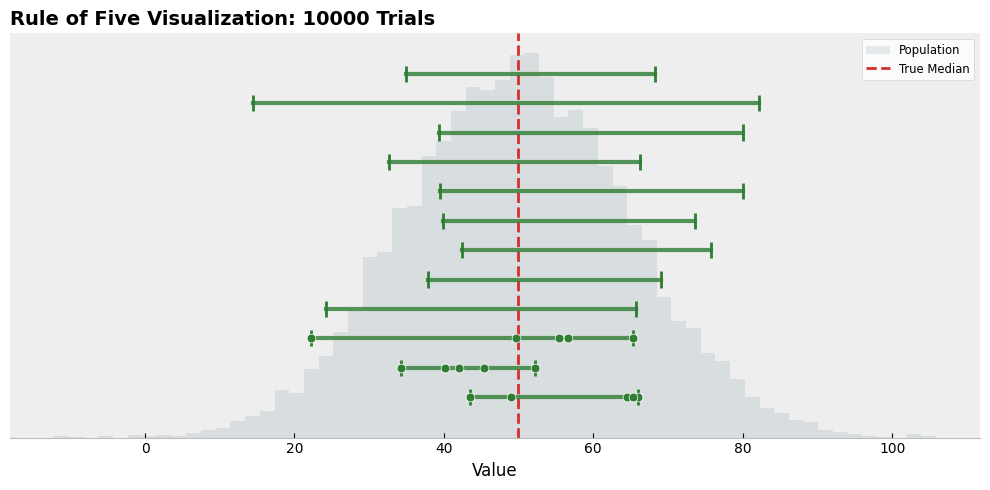

In [21]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
    
# 1. Plot Population Context
ax.hist(population_data, bins=60, color='#607d8b', alpha=0.15, density=True, label='Population')
ax.axvline(population_median, color='#d32f2f', linestyle='--', linewidth=2, label='True Median', zorder=2)

# 2. Setup Visualization Parameters
# Limit visualization to a few samples to prevent overcrowding the UI
viz_count = min(NUM_SIMS, 12)
y_max = ax.get_ylim()[1]

# Distribute ranges vertically across the plot area
y_positions = np.linspace(y_max * 0.1, y_max * 0.9, viz_count)

# 3. Plot Horizontal Ranges
for i in range(viz_count):
    is_success = is_median_within_range_arr[i]
    color = '#2e7d32' if is_success else '#c62828'
    y = y_positions[i]
    
    # Plot perfectly horizontal range line [min, max]
    ax.plot([sample_min[i], sample_max[i]], [y, y], 
            color=color, linewidth=3, alpha=0.8, zorder=3)
    
    # Add vertical end-caps to clearly define the boundaries
    cap_height = y_max * 0.02
    ax.vlines([sample_min[i], sample_max[i]], y - cap_height, y + cap_height, 
              color=color, linewidth=2, zorder=4)
    
    # Plot the 5 original points for visual clarity in small batches
    if NUM_SIMS <= 10 or i < 3:
        ax.scatter(sample_data[i], [y] * 5, color=color, s=40, 
                   edgecolors='white', linewidth=0.5, zorder=5, alpha=1)

# 4. Styling and Labels
ax.set_title(f"Rule of Five Visualization: {NUM_SIMS} Trials", loc='left', fontsize=14, fontweight='bold')
ax.set_xlabel("Value")
ax.get_yaxis().set_visible(False)
ax.legend(loc='upper right', frameon=True, facecolor='white', fontsize='small')

# Modern clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(False) # Remove vertical grid lines for cleaner range view

plt.tight_layout()

## Summarising?

In [26]:
pd.DataFrame([{
    'trials': NUM_SIMS,
    'hits': success_count,
    'accuracy': accuracy_pct,
    'dist_type': "normal"
}])

,trials,hits,accuracy,dist_type
0,10000,9362,93.62,normal


In [28]:
stats_md = (
        f"### Simulation Stats\n"
        f"**Accuracy Rate:** {accuracy_pct:.2f}%  \n"
        f"**Hits/Trials:** {success_count} / {NUM_SIMS}"
    )

In [29]:
type(stats_md)

str